# Lab 3: What makes a good prediction?

In this lab you will:
1. transform df columns
1. define loss functions
1. measure overall prediction error using MSE and R2.

### Collaboration Policy

Data science is a collaborative activity. While you may talk with others about the labs, we ask that you **write your solutions individually**. If you do discuss the assignments with others, please **include their names** at the top of this notebook.

## Setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
np.random.seed(42)
plt.style.use('fivethirtyeight')
sns.set()
sns.set_context("talk")
%matplotlib inline

# Loading the Tips Dataset

To begin with, we load the tips dataset from the `seaborn` library.  The tips data contains records of tips, total bill, and information about the person who paid the bill.

In [2]:
data = sns.load_dataset("tips")

print("Number of Records:", len(data))
data.head()

Number of Records: 244


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Question 1: Transforming Data (and broadcast operations)
Let's create a new column named '%' to reflect what percent of the total bill.

In [7]:
data['%'] = data['tip'] / data['total_bill']

Does the new column look correct?

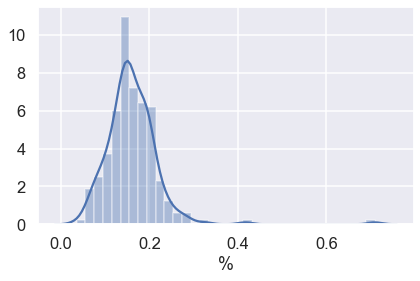

In [8]:
sns.distplot(data['%'])

In [9]:
data['%'].describe()

count    244.000000
mean       0.160803
std        0.061072
min        0.035638
25%        0.129127
50%        0.154770
75%        0.191475
max        0.710345
Name: %, dtype: float64

(Alternative possibility was that total_bill was *after* the tip was added...)

---
<br/><br/><br/>

# Loss Functions

Let's try to predict the tip percentage!

Suppose I predict that everyone tips 15%. Is that a *good* prediction? How could I measure that?

Loss functions quantify how much "off" a prediction is.  In this lab we will implement the squared loss and the absolute loss functions.  

TODO this is old complicated.
Suppose for a given total bill $x$, we observe a tip value of $y$ and our model predicts a tip value $\hat{y}$ by:
$$\Large
% the \hspace{0pt} is added to address a bug in safari mathjax
\hat{\hspace{0pt}y} = \theta x
$$ 
then any of the following might be appropriate **loss functions**

1. **Squared Loss** (also known as the $L^2$ loss pronounced "ell-two"):
$$\Large
% the \hspace{0pt} is added to address a bug in safari mathjax
L\left(y, \hat{\hspace{0pt}y} \right) = \left( y - \hat{\hspace{0pt}y} \right)^2
$$
1. **Absolute Loss** (also known as the $L^1$ loss pronounced "ell-one"):
$$\Large
% the \hspace{0pt} is added to address a bug in safari mathjax
L\left(y, \hat{\hspace{0pt}y} \right) = \left| y - \hat{\hspace{0pt}y} \right|
$$

---
<br></br>
In this question, you are going to define functions for **squared loss** and **absolute loss**. 

## Question 2a: Implement the squared loss function


$$\Large
L\left(y, \hat{\hspace{0pt}y} \right) = \left( y - \hat{\hspace{0pt}y} \right)^2
$$

Using the comments below, implement the squared loss function. Your answer should not use any loops.

<!--
BEGIN QUESTION
name: q2a
-->

In [6]:
def squared_loss(y_obs, y_hat):
    """
    Calculate the squared loss of the observed data and predicted data.
    
    Parameters
    ------------
    y_obs: an array of observed values
    y_hat: an array of predicted values
    
    Returns
    ------------
    An array of loss values corresponding to the squared loss for each prediction
    """
    ...
    ...

## Question 2b: Plotting Squared Loss

Suppose you observe a bill of \\$28 with a tip \\$3. (Does this tip look reasonable?)

In our model, this corresponds to $y=3.00$ and $x=28.00$. Now suppose we pick an initial range of $\theta$'s (tip percent in this case) for you. Use the `model` and `squared_loss` function defined above to plot the loss for a range of $\theta$ values:

<!--
BEGIN QUESTION
name: q2b
-->

In [11]:
y = 3.00
x = 28.00
thetas = np.linspace(0, 0.3, 200) # A range of theta values

## Finish this by replacing 0.0 with the correct calculation 
## Hint: You will use squared_loss y, model, theta and x
#loss should be a numpy array where the ith entry corresponds to the loss for the ith theta
loss = np.array([ 0.0 for theta in thetas])

...

In [ ]:
ok.grade("q2b");

To test your loss calculation above, run the cell below, and it should produce this picture:

![squared loss](squared_loss.png)

In [13]:
plt.plot(thetas, loss, label="Squared Loss")
plt.title("Squared Loss of Observed and Predicted Tip (in dollars)")
plt.xlabel(r"Choice for $\theta$ (tip percent)")
plt.ylabel(r"Loss")
plt.legend(loc=4)
plt.savefig("squared_loss_my_plot.png",  bbox_inches = 'tight')

## Question 2c: Implement the absolute loss 

$$\Large
L\left(y, \hat{\hspace{0pt}y} \right) = \left| y - \hat{\hspace{0pt}y} \right|
$$

<!--
BEGIN QUESTION
name: q2c
-->

In [14]:
def abs_loss(y_obs, y_hat):
    """
    Calculate the absolute loss of the observed data and predicted data.
    
    Parameters
    ------------
    y_obs: an array of observed values
    y_hat: an array of predicted values
    
    Returns
    ------------
    An array of loss values corresponding to the absolute loss for each prediction
    """
    ...
    ...


## Question 2d: Plotting **Average Loss** for our Data
Remember we define our model to be:
$$\Large
% the \hspace{0pt} is added to address a bug in safari mathjax
\hat{\hspace{0pt}y} = \theta x
$$ 
Now, we can extend the above loss functions to an entire dataset by taking the average. Let the dataset $\mathcal{D}$ be the set of observations:

$$\Large
\mathcal{D} = \{(x_1, y_1), \ldots, (x_n, y_n)\}
$$

where $x_i$ is the total bill and $y_i$ is the tip dollar amount.

We can define the average loss over the dataset as:

$$\Large
L\left(\theta, \mathcal{D}\right) = \frac{1}{n} \sum_{i=1}^n L(m_\theta(x_i), y_i) = \frac{1}{n} \sum_{i=1}^n L(\theta x_i, y_i) = \frac{1}{n} \sum_{i=1}^n L(\hat{y_i}, y_i)
$$

where $m_\theta(x_i) = \theta x_i = \hat{y_i}$ is the model evaluated using the parameters $\theta$ on the bill amount $x_i$.

**Complete the following code block to render a plot of the average absolute and squared loss for different values of $\theta$**

In [20]:
thetas = np.linspace(0, 0.3, 200) # A range of theta values
y = data['tip']
x = data['total_bill']

# Replace 0.0 with the correct value computed 
# Use the model and loss functions from above

# This time, each loss array should be a numpy array where the ith entry corresponds to the 
# average loss across all data points for the ith theta

avg_squared_loss = np.array([0.0 for theta in thetas])
avg_absolute_loss = np.array([0.0 for theta in thetas])

...

To test your loss calculations, run the cell below. If your code was correct, the following plot should look like:

![Average Loss](average_loss.png)

Note: Your colors might be different.

In [21]:
plt.plot(thetas, avg_squared_loss, label = "Average Squared Loss")
plt.plot(thetas, avg_absolute_loss, label = "Average Absolute Loss")
plt.title("Average Squared and Absolute Loss of Observed and Predicted Tip (in dollars)")
plt.xlabel(r"Choice for $\theta$ (tip percent)")
plt.ylabel(r"Loss")
plt.legend()
plt.savefig("average_loss_my_plot.png",  bbox_inches = 'tight')

**Based on the plot above, approximately what is the optimal value of theta you would choose for this model?**

## How to minimize that loss?

What is the average loss you get for each of the following tip percentages (fill in the table)

guess | mean squared error | mean absolute error
-----|---|---
0.15 |? | ?
0.4 | ? | ?
`data['%'].mean()` | ? | ?
`data['%'].mean() + .0001` | ? | ?
`data['%'].mean() - .0001` | ? | ?
`data['%'].median()` | ? | ?
`data['%'].median() + .0001` | ? | ?
`data['%'].median() - .0001` | ? | ?


Based on your observations, what guess minimizes the MSE? the MAE?

## Using a model to make predictions

Our predictive model was too simple: we assumed that everyone would leave the same tip. But we might be able to make a better guess by taking into account some characteristics. Look at the data (repeated again below) -- there are several columns that might plausibly help us make that prediction. Maybe men and women tip different amounts? Maybe people tip more or less on certain days of the week? Maybe larger parties tip more--orless? Maybe people tip more for fancier meals (reflected in the total bill)?

## Q: Predict using gender

1. Guess, measure, improve guess

In [ ]:
def predict_pct_from_gender(gender, )

2. How could we do it in a more principled way?

In [13]:
data.groupby('sex')['%'].mean()

sex
Male      0.157651
Female    0.166491
Name: %, dtype: float64

In [16]:
data['%'].mean()

0.16080258172250472

In [15]:
data['%'].groupby(data['sex']).mean()

sex
Male      0.157651
Female    0.166491
Name: %, dtype: float64

How good is that? (MSE)

How much better is it than just predicting the mean (R2)?
